<a href="https://colab.research.google.com/github/Ronald-Tuncar/LAB10/blob/develop/LAB10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [ ]:
# Carga de datos
df = pd.read_csv("vehículos.csv")

# Eliminación de columnas no requeridas
columnas_a_eliminar = ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']
df.drop(columns=columnas_a_eliminar, inplace=True)

# Imputación de datos faltantes
imputador_num = SimpleImputer(strategy='mean')
imputador_cat = SimpleImputer(strategy='most_frequent')

df[['desplazamiento', 'cilindros']] = imputador_num.fit_transform(df[['desplazamiento', 'cilindros']])
df[['tamano_motor_tipo']] = imputador_cat.fit_transform(df[['tamano_motor_tipo']])

In [ ]:
# Tratamiento de outliers univariado
def tratar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LI = Q1 - 1.5 * IQR
    LS = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < LI, LI, df[col])
    df[col] = np.where(df[col] > LS, LS, df[col])
    return df

variables_numericas = ['desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
for col in variables_numericas:
    df = tratar_outliers_iqr(df, col)

# Tratamiento de outliers multivariado (Isolation Forest)
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.02, random_state=42)
outliers = iso.fit_predict(df[variables_numericas])
df = df[outliers == 1]  # solo dejamos los datos normales

# Separar variables numéricas y categóricas
numericas = ['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
categoricas = ['traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

# Escalamiento y dumificación
preprocesador = ColumnTransformer([
    ('num', StandardScaler(), numericas),
    ('cat', OneHotEncoder(drop='first'), categoricas)
])

X = preprocesador.fit_transform(df)

# Guardamos también la columna objetivo para evaluación externa
y_real = df['clase_tipo']

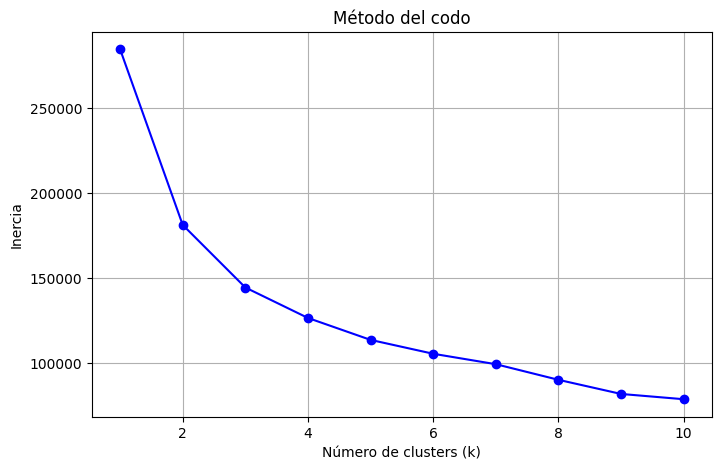

In [ ]:
# Método del codo para elegir K óptimo
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8,5))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.show()

In [ ]:
# Seleccionamos k óptimo basado en el codo
k_optimo = 4  # ajusta este número tras ver la gráfica del codo
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X)

# Añadir la columna de cluster al dataframe original
df['cluster'] = clusters

# Comparar conglomerados: estadísticas por cluster
agrupados = df.groupby('cluster')[numericas].mean()
print(agrupados)

                year  desplazamiento  cilindros         co2  \
cluster                                                       
0        2003.470119        1.951816   4.070503  333.228677   
1        1999.541373        5.114211   7.704780  619.919387   
2        1999.547398        3.304099   5.789929  484.881248   
3        2001.832718        2.527268   4.703259  406.571450   

         consumo_litros_milla  
cluster                        
0                    0.141577  
1                    0.260806  
2                    0.206372  
3                    0.172975  


In [ ]:
sil_score = silhouette_score(X, clusters)
calinski = calinski_harabasz_score(X, clusters)
davies = davies_bouldin_score(X, clusters)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.2f}")
print(f"Davies-Bouldin Index: {davies:.4f}")

Silhouette Score: 0.2609
Calinski-Harabasz Index: 15060.62
Davies-Bouldin Index: 1.4793


In [ ]:
# Reentrenar con 8 clusters
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init='auto')
clusters_8 = kmeans_8.fit_predict(X)

# Evaluación externa comparando con la variable 'clase_tipo'
ari = adjusted_rand_score(y_real, clusters_8)
nmi = normalized_mutual_info_score(y_real, clusters_8)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.0523
Normalized Mutual Information (NMI): 0.1301
